In [1]:
from datetime import timedelta
import numpy as np
import pandas as pd
import xarray as xr
import dask
import re
import matplotlib.pyplot as plt

Data Intake

This will also be code for trying different testing data. 
We will get this directly from Dale Allens directory and I will transform the data and save it as transformationed data 

In [2]:
#14 months worth of data and 13 variables 
#This is for a select number of variables
directory1 = '/aosc/eos20/djallen/lightning/geos/twod/202306/'
directory2 = '/aosc/eos20/djallen/lightning/geos/twod/202307/'
directory3 = '/aosc/eos20/djallen/lightning/geos/twod/202308/'
directory4 = '/aosc/eos20/djallen/lightning/geos/twod/202309/'
directory5 = '/aosc/eos20/djallen/lightning/geos/twod/202310/'
directory6 = '/aosc/eos20/djallen/lightning/geos/twod/202311/'
directory7 = '/aosc/eos20/djallen/lightning/geos/twod/202312/'
directory8 = '/aosc/eos20/djallen/lightning/geos/twod/202401/'
directory9 = '/aosc/eos20/djallen/lightning/geos/twod/202402/'
directory10 = '/aosc/eos20/djallen/lightning/geos/twod/202403/'
directory11 = '/aosc/eos20/djallen/lightning/geos/twod/202404/'
directory12 = '/aosc/eos20/djallen/lightning/geos/twod/202405/'
directory13 = '/aosc/eos20/djallen/lightning/geos/twod/202406/'
directory14 = '/aosc/eos20/djallen/lightning/geos/twod/202407/'
directory15 = '/aosc/eos20/djallen/lightning/geos/twod/202408/'
directory16 = '/aosc/eos20/djallen/lightning/geos/twod/202409/'
directory17 = '/aosc/eos20/djallen/lightning/geos/twod/202410/'
directory18 = '/aosc/eos20/djallen/lightning/geos/twod/202411/'
directory19 = '/aosc/eos20/djallen/lightning/geos/twod/202412/'

#Cape
file_paths = [
    # directory1 + 'GEOSv11.7.0_cape_hrly.UT.t202306.r180W-180E_90S-90N.nc',
    # directory2 + 'GEOSv11.7.0_cape_hrly.UT.t202307.r180W-180E_90S-90N.nc',
    # directory3 + 'GEOSv11.7.0_cape_hrly.UT.t202308.r180W-180E_90S-90N.nc',
    # directory4 + 'GEOSv11.7.0_cape_hrly.UT.t202309.r180W-180E_90S-90N.nc',
    # directory5 + 'GEOSv11.7.0_cape_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_cape_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_cape_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_cape_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_cape_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_cape_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_cape_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_cape_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_cape_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_cape_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_cape_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_cape_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_cape_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_cape_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_cape_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
#ConvPre
file_paths_Convpre = [
    # directory1 + 'GEOSv11.7.0_precon_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_precon_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_precon_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_precon_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_precon_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_precon_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_precon_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_precon_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_precon_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_precon_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_precon_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_precon_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_precon_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_precon_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_precon_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_precon_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_precon_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_precon_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_precon_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]

#Cloud Height 
file_paths_CldHT = [
    # directory1 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_z_cldht_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
# #700-500hPa Lapse Rate
file_paths_LR = [
    # directory1 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_t_lapserate_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
# #Moist Static Energy Ratio 
file_paths_MSE = [
    # directory1 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_mse_ratio_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
#Column Integrated Relative Humidity
file_paths_cRH = [
    # directory1 + 'GEOSv11.7.0_crh_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_crh_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_crh_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_crh_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_crh_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_crh_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_crh_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_crh_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_crh_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_crh_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_crh_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_crh_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_crh_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_crh_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_crh_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_crh_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_crh_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_crh_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_crh_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
# #Maximum Cloud Fraction noted as: Largest CLCN in column...Dale has something different he wants me to use: 
file_paths_MaxFrac = [
    # directory1 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_clcn_colmax_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
#Total Precipitation 
file_paths_totPrecip = [
    # directory1 + 'GEOSv11.7.0_pretot_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_pretot_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_pretot_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_pretot_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_pretot_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_pretot_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_pretot_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_pretot_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_pretot_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_pretot_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_pretot_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_pretot_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_pretot_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_pretot_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_pretot_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_pretot_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_pretot_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_pretot_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_pretot_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
#Ice FLux 
file_paths_iceflux = [
    # directory1 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_pfi_cn_colmax_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]
#LCL
file_paths_LCL = [
#   directory1 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202306.r180W-30W_50S-50N.nc',
#     directory2 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202307.r180W-30W_50S-50N.nc',
#     directory3 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202308.r180W-30W_50S-50N.nc',
#     directory4 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202309.r180W-30W_50S-50N.nc',
#     directory5 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202310.r180W-30W_50S-50N.nc',
#     directory6 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202311.r180W-30W_50S-50N.nc',
#     directory7 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202312.r180W-30W_50S-50N.nc',
#     directory8 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202401.r180W-30W_50S-50N.nc',
#     directory9 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202402.r180W-30W_50S-50N.nc',
#     directory10 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202403.r180W-30W_50S-50N.nc',
#     directory11 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202404.r180W-30W_50S-50N.nc',
#     directory12 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202405.r180W-30W_50S-50N.nc',
#     directory13 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_lcl_moist_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]


In [3]:
#This is for the Aerosols. 
#PM Fine
file_paths_PMfine = [
  directory1 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_pm_fine_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]
#PM Coarse
file_paths_PMcoarse = [
  directory1 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_pm_coarse_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]


In [4]:
#This is for the Aerosols.
#Black Carbon  
file_paths_BCtau = [
  directory1 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_bc_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Brown Carbon  
file_paths_BRtau = [
  directory1 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_br_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Dust 
file_paths_Dusttau = [
  directory1 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_du_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Nitrate
file_paths_Nitratetau = [
  directory1 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_ni_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Organic Carbon 
file_paths_OCtau = [
  directory1 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_oc_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Sea Salt
file_paths_SeaSalttau = [
  directory1 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_ss_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

#Sulfate
file_paths_Suflatetau = [
  directory1 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    directory2 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    directory3 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    directory4 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    directory5 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    directory6 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    directory7 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    directory8 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    directory9 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    directory10 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    directory11 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    directory12 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    directory13 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202407.r180W-30W_50S-50N.nc',
    directory15 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202408.r180W-30W_50S-50N.nc',
    directory16 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202409.r180W-30W_50S-50N.nc',
    directory17 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202410.r180W-30W_50S-50N.nc',
    directory18 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202411.r180W-30W_50S-50N.nc',
    directory19 + 'GEOSv11.7.0_tau_su_ext_hrly.UT.t202412.r180W-30W_50S-50N.nc'
]

In [6]:
#LWI Variable:
file_paths_LWI = [
    # directory1 + 'GEOSv11.7.0_lwi_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_lwi_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_lwi_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_lwi_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_lwi_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_lwi_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_lwi_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_lwi_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_lwi_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_lwi_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_lwi_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_lwi_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_lwi_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_lwi_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_lwi_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_lwi_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_lwi_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_lwi_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_lwi_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]

In [3]:
#This is for a select number of variables that are at 440
directory20 = '/aosc/eos20/djallen/lightning/geos/twod_440/202306/'
directory21 = '/aosc/eos20/djallen/lightning/geos/twod_440/202307/'
directory22 = '/aosc/eos20/djallen/lightning/geos/twod_440/202308/'
directory23 = '/aosc/eos20/djallen/lightning/geos/twod_440/202309/'
directory24 = '/aosc/eos20/djallen/lightning/geos/twod_440/202310/'
directory25 = '/aosc/eos20/djallen/lightning/geos/twod_440/202311/'
directory26 = '/aosc/eos20/djallen/lightning/geos/twod_440/202312/'
directory27 = '/aosc/eos20/djallen/lightning/geos/twod_440/202401/'
directory28 = '/aosc/eos20/djallen/lightning/geos/twod_440/202402/'
directory29 = '/aosc/eos20/djallen/lightning/geos/twod_440/202403/'
directory30 = '/aosc/eos20/djallen/lightning/geos/twod_440/202404/'
directory31 = '/aosc/eos20/djallen/lightning/geos/twod_440/202405/'
directory32 = '/aosc/eos20/djallen/lightning/geos/twod_440/202406/'
directory33 = '/aosc/eos20/djallen/lightning/geos/twod_440/202407/'
directory34 = '/aosc/eos20/djallen/lightning/geos/twod_440/202408/'
directory35 = '/aosc/eos20/djallen/lightning/geos/twod_440/202409/'
directory36 = '/aosc/eos20/djallen/lightning/geos/twod_440/202410/'
directory37 = '/aosc/eos20/djallen/lightning/geos/twod_440/202411/'
directory38 = '/aosc/eos20/djallen/lightning/geos/twod_440/202412/'
# #massflux
file_paths_massflux = [
    # directory20 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory21 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory22 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory23 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory24 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory25 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory26 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory27 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory28 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory29 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory30 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory31 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory32 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory33 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory34 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory35 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory36 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory37 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory38 + 'GEOSv11.7.0_cnv_mfc_440_hrly.UT.t202412.r180W-180E_90S-90N.nc',
]
#convective cloud fraction
file_paths_cloudfrac = [
    # directory20 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory21 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory22 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory23 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory24 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory25 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory26 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory27 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory28 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory29 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory30 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory31 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory32 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory33 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory34 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory35 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory36 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory37 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory38 + 'GEOSv11.7.0_cldfrac_conv_440_hrly.UT.t202412.r180W-180E_90S-90N.nc',
]
# #IWC at 440hpa
file_paths_iwc = [
    # directory20 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory21 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory22 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory23 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory24 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory25 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory26 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory27 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory28 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory29 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory30 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory31 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory32 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory33 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory34 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory35 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory36 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory37 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory38 + 'GEOSv11.7.0_iwc_440_hrly.UT.t202412.r180W-180E_90S-90N.nc',
]

In [4]:
#This is for Lopez. 
file_paths_lopez = [
    # directory1 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202306.r180W-30W_50S-50N.nc',
    # directory2 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202307.r180W-30W_50S-50N.nc',
    # directory3 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202308.r180W-30W_50S-50N.nc',
    # directory4 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202309.r180W-30W_50S-50N.nc',
    # directory5 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202310.r180W-30W_50S-50N.nc',
    # directory6 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202311.r180W-30W_50S-50N.nc',
    # directory7 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202312.r180W-30W_50S-50N.nc',
    # directory8 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202401.r180W-30W_50S-50N.nc',
    # directory9 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202402.r180W-30W_50S-50N.nc',
    # directory10 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202403.r180W-30W_50S-50N.nc',
    # directory11 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202404.r180W-30W_50S-50N.nc',
    # directory12 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202405.r180W-30W_50S-50N.nc',
    # directory13 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202406.r180W-30W_50S-50N.nc',
    directory14 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202407.r180W-180E_90S-90N.nc',
    directory15 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202408.r180W-180E_90S-90N.nc',
    directory16 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202409.r180W-180E_90S-90N.nc',
    directory17 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202410.r180W-180E_90S-90N.nc',
    directory18 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202411.r180W-180E_90S-90N.nc',
    directory19 + 'GEOSv11.7.0_lfr_lopez_hrly.UT.t202412.r180W-180E_90S-90N.nc'
]

In [7]:
#Bring in the MTG Data here. 
file_paths_MTG = [
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202407.r40W-40E_40S-40N.nc',
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202408.r40W-40E_40S-40N.nc',
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202409.r40W-40E_40S-40N.nc',
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202410.r40W-40E_40S-40N.nc',
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202411.r40W-40E_40S-40N.nc', 
   '/aosc/eos20/djallen/data/lightning/MTG_LI/2024/MTG_LIDEadj_hrly_count_f.UT.t202412.r40W-40E_40S-40N.nc', 
 
]

In [8]:
def latlon_correction1(ds, year, month, variable_name):
    # Compute the datetime range
    datetime_range = pd.date_range(
        start=f"{year}-{month}-01", 
        freq="1H", 
        periods=len(ds.Days)*len(ds.Hours)
    )
    datetime_range = datetime_range + timedelta(hours=1)
    # Apply the coordinate corrections and assign the new time coordinates
    ds_corrected = ds.assign_coords(
        coords=dict(
            Longitudes=ds.longitude,
            Latitudes=ds.latitude,
            time=datetime_range
        )
    ).drop_vars(
        names=["longitude", "latitude", "time"]
    ).stack(Datetime=["Days","Hours"])[variable_name].assign_attrs(
    missing_value=np.nan).to_dataset(
    name=variable_name).drop_vars("Datetime").assign_coords(
    coords=dict(
        Datetime=datetime_range,
    )
)
    return ds_corrected

In [9]:
def extract_year_month(filename):
    match = re.search(r'(\d{4})(\d{2})', filename)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return year, month
    else:
        raise ValueError(f"Cannot extract year and month from filename: {filename}")

In [10]:
def process_file(filename):
    # Extract the year and month from the filename using regular expressions
    match = re.search(r'(\d{4})(\d{2})', filename)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
    else:
        raise ValueError(f"Cannot extract year and month from filename: {filename}")

    # Load the dataset
    ds = xr.open_dataset(filename)

    # Apply the latlon_correction function
    ds_corrected = latlon_correction1(ds, year, month, "energy_f")

    return ds_corrected

In [11]:
class PreprocessWrapper:
    def __init__(self, file_paths, variable_name):
        self.file_paths = file_paths
        self.variable_name = variable_name
    def preprocess(self, ds):
        # Extract the filename from the dataset's encoding source
        filename = ds.encoding['source']
        year, month = extract_year_month(filename)
        ds_corrected = latlon_correction1(ds, year, month, self.variable_name)
        return ds_corrected

In [12]:
wrapper = PreprocessWrapper(file_paths, variable_name = 'cape')
#Cape
datasets_cape = xr.open_mfdataset(file_paths, combine='nested', concat_dim='Datetime', preprocess=wrapper.preprocess)
wrapper1 = PreprocessWrapper(file_paths_Convpre, variable_name = 'precon')
#precon
datasets_conpre = xr.open_mfdataset(file_paths_Convpre, combine='nested', concat_dim='Datetime', preprocess=wrapper1.preprocess)
#Mass Flux @440
wrapper2 = PreprocessWrapper(file_paths_massflux, variable_name = 'cnv_mfc_440')
#Convective Mass Flux
datasets_massflux = xr.open_mfdataset(file_paths_massflux, combine='nested', concat_dim='Datetime', preprocess=wrapper2.preprocess)
wrapper3 = PreprocessWrapper(file_paths_cloudfrac, variable_name = 'cldfrac_conv_440')
#Convective Cloud fraction @ 440hPa
datasets_cloudfrac = xr.open_mfdataset(file_paths_cloudfrac, combine='nested', concat_dim='Datetime', preprocess=wrapper3.preprocess)
wrapper4 = PreprocessWrapper(file_paths_iwc, variable_name = 'iwc_440')
#IWC @ 440 hPa
datasets_iwc440 = xr.open_mfdataset(file_paths_iwc, combine='nested', concat_dim='Datetime', preprocess=wrapper4.preprocess)
wrapper5 = PreprocessWrapper(file_paths_CldHT, variable_name = 'z_cldht')
#Temperature Lapse Rate 
datasets_cldht = xr.open_mfdataset(file_paths_CldHT, combine='nested', concat_dim='Datetime', preprocess=wrapper5.preprocess)
wrapper6 = PreprocessWrapper(file_paths_LR, variable_name = 't_lapserate')
#MSE Ratio
datasets_tlapse = xr.open_mfdataset(file_paths_LR, combine='nested', concat_dim='Datetime', preprocess=wrapper6.preprocess)
wrapper7 = PreprocessWrapper(file_paths_MSE, variable_name = 'mse_ratio')
datasets_mseratio = xr.open_mfdataset(file_paths_MSE, combine='nested', concat_dim='Datetime', preprocess=wrapper7.preprocess)
#Column Relative Humidity
wrapper8 = PreprocessWrapper(file_paths_cRH, variable_name = 'crh')
datasets_crh = xr.open_mfdataset(file_paths_cRH, combine='nested', concat_dim='Datetime', preprocess=wrapper8.preprocess)
#Maximum Cloud Fratction 
wrapper9 = PreprocessWrapper(file_paths_MaxFrac, variable_name = 'clcn_colmax')
datasets_MaxFrac = xr.open_mfdataset(file_paths_MaxFrac, combine='nested', concat_dim='Datetime', preprocess=wrapper9.preprocess)
#Total Precipitation 
wrapper10 = PreprocessWrapper(file_paths_totPrecip, variable_name = 'pretot')
datasets_totPrecip = xr.open_mfdataset(file_paths_totPrecip, combine='nested', concat_dim='Datetime', preprocess=wrapper10.preprocess)
#Ice Flux 
wrapper12 = PreprocessWrapper(file_paths_iceflux, variable_name = 'pfi_cn_colmax')
datasets_iceflux = xr.open_mfdataset(file_paths_iceflux, combine='nested', concat_dim='Datetime', preprocess=wrapper12.preprocess)

/tmp/ipykernel_406757/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_406757/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Hours', 'Days'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_406757/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_406757/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Hours', 'Days'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_406757/

In [13]:
#LCL Moist
wrapper13 = PreprocessWrapper(file_paths_LCL, variable_name = 'lcl_moist')
datasets_LCL = xr.open_mfdataset(file_paths_LCL, combine='nested', concat_dim='Datetime', preprocess=wrapper13.preprocess)
#LWI Variable: 
wrapper14 = PreprocessWrapper(file_paths_LWI, variable_name = 'lwi')
datasets_LWI = xr.open_mfdataset(file_paths_LWI, combine='nested', concat_dim='Datetime', preprocess=wrapper14.preprocess)
#Lopez Data: 
wrapper15 = PreprocessWrapper(file_paths_lopez, variable_name = 'lfr')
datasets_Lopez = xr.open_mfdataset(file_paths_lopez, combine='nested', concat_dim='Datetime', preprocess=wrapper15.preprocess)
#MTG Data:
wrapper16 = PreprocessWrapper(file_paths_MTG, variable_name = 'flashes')
datasets_MTG = xr.open_mfdataset(file_paths_MTG, combine='nested', concat_dim='Datetime', preprocess=wrapper16.preprocess)


/tmp/ipykernel_406757/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_406757/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Hours', 'Days'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_406757/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_406757/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Hours', 'Days'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_406757/

In [14]:
#PM Coarse
wrapper16 = PreprocessWrapper(file_paths_PMcoarse, variable_name = 'pm_coarse')
datasets_PMCoarse = xr.open_mfdataset(file_paths_PMcoarse, combine='nested', concat_dim='Datetime', preprocess=wrapper16.preprocess)
#PM Fine 
wrapper17 = PreprocessWrapper(file_paths_PMfine, variable_name = 'pm_fine')
datasets_PMFine = xr.open_mfdataset(file_paths_PMfine, combine='nested', concat_dim='Datetime', preprocess=wrapper17.preprocess)


/tmp/ipykernel_139785/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_139785/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Days', 'Hours'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_139785/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_139785/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Days', 'Hours'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_139785/

In [15]:
#Black Carbon
wrapper18 = PreprocessWrapper(file_paths_BCtau, variable_name = 'tau_bc_ext')
datasets_BC = xr.open_mfdataset(file_paths_BCtau, combine='nested', concat_dim='Datetime', preprocess=wrapper18.preprocess)
#Brown Carbon  
wrapper19 = PreprocessWrapper(file_paths_BRtau, variable_name = 'tau_br_ext')
datasets_BR = xr.open_mfdataset(file_paths_BRtau, combine='nested', concat_dim='Datetime', preprocess=wrapper19.preprocess)
#Dust 
wrapper20 = PreprocessWrapper(file_paths_Dusttau, variable_name = 'tau_du_ext')
datasets_Dust = xr.open_mfdataset(file_paths_Dusttau, combine='nested', concat_dim='Datetime', preprocess=wrapper20.preprocess)
#Nitrate  
wrapper21 = PreprocessWrapper(file_paths_Nitratetau, variable_name = 'tau_ni_ext')
datasets_Nitrate = xr.open_mfdataset(file_paths_Nitratetau, combine='nested', concat_dim='Datetime', preprocess=wrapper21.preprocess)
#Organic Carbon   
wrapper22 = PreprocessWrapper(file_paths_OCtau, variable_name = 'tau_oc_ext')
datasets_OC = xr.open_mfdataset(file_paths_OCtau, combine='nested', concat_dim='Datetime', preprocess=wrapper22.preprocess)
#Sea Salt  
wrapper23 = PreprocessWrapper(file_paths_SeaSalttau, variable_name = 'tau_ss_ext')
datasets_SS = xr.open_mfdataset(file_paths_SeaSalttau, combine='nested', concat_dim='Datetime', preprocess=wrapper23.preprocess)
#Sulfate  
wrapper24 = PreprocessWrapper(file_paths_Suflatetau, variable_name = 'tau_su_ext')
datasets_Sulfate = xr.open_mfdataset(file_paths_Suflatetau, combine='nested', concat_dim='Datetime', preprocess=wrapper24.preprocess)


/tmp/ipykernel_139785/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_139785/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Days', 'Hours'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_139785/961066084.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_range = pd.date_range(
/tmp/ipykernel_139785/961066084.py:20: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'Days', 'Hours'} to avoid an error in the future.
  name=variable_name).drop_vars("Datetime").assign_coords(
/tmp/ipykernel_139785/

In [12]:
#32x32 degree domain making a 64x64 grid this is for the USA domain
# cape_data = datasets_cape.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# convpre_data = datasets_conpre.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# massflux_data = datasets_massflux.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# iwc440_data = datasets_iwc440.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# cldht_data = datasets_cldht.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# tlapse_data = datasets_tlapse.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# mseratio_data = datasets_mseratio.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# crh_data = datasets_crh.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# pretot_data = datasets_totPrecip.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# iceflux_data = datasets_iceflux.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# LCL_data = datasets_LCL.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# LWI_data = datasets_LWI.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# lopez_data = datasets_Lopez.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))


#Aerosols
# pmcoarse_data = datasets_PMCoarse.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# pmfine_data = datasets_PMFine.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# OC_data = datasets_OC.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# BC_data = datasets_BC.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# BR_data = datasets_BR.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# Dust_data = datasets_Dust.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# Nitrate_data = datasets_Nitrate.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# Sulfate_data = datasets_Sulfate.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
# Seasalt_data = datasets_SS.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
#Yes, these have been checked. The shape is (64,64,10272)

In [12]:
# #This is for the North Pacific Domain 
# cape_data = datasets_cape.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# convpre_data = datasets_conpre.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# massflux_data = datasets_massflux.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# iwc440_data = datasets_iwc440.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# cldht_data = datasets_cldht.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# tlapse_data = datasets_tlapse.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# mseratio_data = datasets_mseratio.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# crh_data = datasets_crh.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# pretot_data = datasets_totPrecip.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# iceflux_data = datasets_iceflux.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# LCL_data = datasets_LCL.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# LWI_data = datasets_LWI.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
# lopez_data = datasets_Lopez.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))

In [13]:
# #This is for the ITCZ Domain 
# cape_data = datasets_cape.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# convpre_data = datasets_conpre.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# massflux_data = datasets_massflux.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# iwc440_data = datasets_iwc440.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# cldht_data = datasets_cldht.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# tlapse_data = datasets_tlapse.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# mseratio_data = datasets_mseratio.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# crh_data = datasets_crh.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# pretot_data = datasets_totPrecip.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# iceflux_data = datasets_iceflux.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# LCL_data = datasets_LCL.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# LWI_data = datasets_LWI.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
# lopez_data = datasets_Lopez.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))

In [12]:
# #This is for the northern ITCZ Domain 
# cape_data = datasets_cape.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# convpre_data = datasets_conpre.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# massflux_data = datasets_massflux.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# iwc440_data = datasets_iwc440.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# cldht_data = datasets_cldht.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# tlapse_data = datasets_tlapse.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# mseratio_data = datasets_mseratio.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# crh_data = datasets_crh.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# pretot_data = datasets_totPrecip.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# iceflux_data = datasets_iceflux.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# LCL_data = datasets_LCL.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# LWI_data = datasets_LWI.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
# lopez_data = datasets_Lopez.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))

In [20]:
#This is for the northern Africa Domain 
cape_data = datasets_cape.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
convpre_data = datasets_conpre.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
massflux_data = datasets_massflux.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
iwc440_data = datasets_iwc440.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
cldht_data = datasets_cldht.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
tlapse_data = datasets_tlapse.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
mseratio_data = datasets_mseratio.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
crh_data = datasets_crh.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
pretot_data = datasets_totPrecip.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
iceflux_data = datasets_iceflux.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
LCL_data = datasets_LCL.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
LWI_data = datasets_LWI.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
lopez_data = datasets_Lopez.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))
MTG_data = datasets_MTG.sel(Longitudes=slice(8,40), Latitudes=slice(-16, 16))

In [14]:
#Smaller African Domain 
cape_data = datasets_cape.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
convpre_data = datasets_conpre.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
massflux_data = datasets_massflux.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
cloudfrac_data = datasets_cloudfrac.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
iwc440_data = datasets_iwc440.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
cldht_data = datasets_cldht.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
tlapse_data = datasets_tlapse.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
mseratio_data = datasets_mseratio.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
crh_data = datasets_crh.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
MaxFrac_data = datasets_MaxFrac.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
pretot_data = datasets_totPrecip.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
iceflux_data = datasets_iceflux.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
LCL_data = datasets_LCL.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
LWI_data = datasets_LWI.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
lopez_data = datasets_Lopez.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))
MTG_data = datasets_MTG.sel(Longitudes=slice(-15,10), Latitudes=slice(5, 30))

In [15]:
lopez_data

<xarray.Dataset>
Dimensions:     (Longitudes: 50, Latitudes: 50, Datetime: 4416)
Coordinates:
  * Longitudes  (Longitudes) float32 -14.75 -14.25 -13.75 ... 8.75 9.25 9.75
  * Latitudes   (Latitudes) float32 5.25 5.75 6.25 6.75 ... 28.75 29.25 29.75
  * Datetime    (Datetime) datetime64[ns] 2024-07-01T01:00:00 ... 2025-01-01
Data variables:
    lfr         (Latitudes, Longitudes, Datetime) float32 dask.array<chunksize=(50, 50, 744), meta=np.ndarray>

In [17]:
# #This will be for testing and training. We want the amazon data for the entirity of the 14 months to eventually put into training, 
# #but right now we want only a few months worth of data for testing. 
# cape_data_amazon = datasets_cape.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# convpre_data_amazon = datasets_conpre.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# massflux_data_amazon = datasets_massflux.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# cloudfrac_data_amazon = datasets_cloudfrac.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# iwc440_data_amazon = datasets_iwc440.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# cldht_data_amazon = datasets_cldht.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# tlapse_data_amazon = datasets_tlapse.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# mseratio_data_amazon = datasets_mseratio.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# crh_data_amazon = datasets_crh.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# MaxFrac_data_amazon = datasets_MaxFrac.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# pretot_data_amazon = datasets_totPrecip.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# iceflux_data_amazon = datasets_iceflux.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# LCL_data_amazon = datasets_LCL.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# LWI_data_amazon = datasets_LWI.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# lopez_data_amazon = datasets_Lopez.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))

# #Aerosols
# pmcoarse_data_amazon = datasets_PMCoarse.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# pmfine_data_amazon = datasets_PMFine.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# OC_data_amazon = datasets_OC.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# BC_data_amazon = datasets_BC.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# BR_data_amazon = datasets_BR.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# Dust_data_amazon = datasets_Dust.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# Nitrate_data_amazon = datasets_Nitrate.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# Sulfate_data_amazon = datasets_Sulfate.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))
# Seasalt_data_amazon = datasets_SS.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))

In [16]:
#Replace the missing values in Cape with Nan
cape_data['cape'] = cape_data['cape'].where(cape_data['cape'] <= 1e7, np.nan)
#Replace the missing values in Cloud Height with Nan
cldht_data['z_cldht'] = cldht_data['z_cldht'].where(cldht_data['z_cldht'] <= 1e7, np.nan)
#Replace the missing values in Cape with Nan
# cape_data_amazon['cape'] = cape_data_amazon['cape'].where(cape_data_amazon['cape'] <= 1e7, np.nan)
# #Replace the missing values in Cloud Height with Nan
# cldht_data_amazon['z_cldht'] = cldht_data_amazon['z_cldht'].where(cldht_data_amazon['z_cldht'] <= 1e7, np.nan)

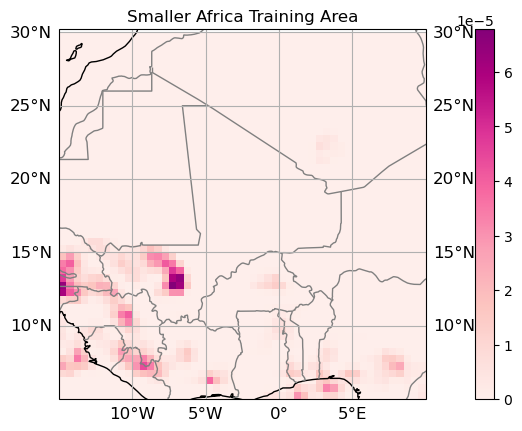

In [17]:
# #Shows the training area for Africa
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Shows the training area for New Domain
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
#This is for the US
def truncate_colormap(cmap, minval=0.05, maxval=0.85, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Create lighter version of RdPu
light_rdpu = truncate_colormap(plt.get_cmap('RdPu'), 0.05, 0.85)

# Select the specific time slice
lwi_slice = iwc440_data['iwc_440'].isel(Datetime=200)

# Create a plot with Cartopy
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data with the new lightened colormap
plot = lwi_slice.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap=light_rdpu, add_colorbar=False
)

# Add and label the colorbar
cbar = plt.colorbar(plot, ax=ax, orientation='vertical', pad=0.1, fraction=0.046)
#cbar.set_label("Land (1) Ocean (0)")

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='gray', linewidth=1) # <--- ADDED COUNTRY LINES HERE
ax.add_feature(cfeature.STATES, linestyle=':')

# Add styled gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.color = 'grey'
gl.linewidth = 1
gl.xlabel_style = {'fontsize': 12}
gl.ylabel_style = {'fontsize': 12}


# Set extent and title
ax.set_extent([-15,10, 5, 30])
ax.set_title('Smaller Africa Training Area', fontsize = 12)

plt.show()

FLash Data

In [16]:
#Flash Data
directory111 = '/aosc/eos20/djallen/data/lightning/glm/2023/'
directory222 = '/aosc/eos20/djallen/data/lightning/glm/2024/'

file_paths_flashes = [
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202306.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202307.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202308.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202309.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202310.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202311.r180W-30W_50S-50N.nc',
    directory111 + 'GLMde2_hrly_count_f.nominalq.UT.t202312.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202401.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202402.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202403.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202404.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202405.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202406.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202407.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202408.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202409.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202410.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202411.r180W-30W_50S-50N.nc',
    directory222 + 'GLMde2_hrly_count_f.nominalq.UT.t202412.r180W-30W_50S-50N.nc',
]

In [18]:
wrapper333 = PreprocessWrapper(file_paths_flashes, variable_name='flashes')
datasets_glm = xr.open_mfdataset(file_paths_flashes, combine='nested', concat_dim='Datetime', preprocess=wrapper333.preprocess)

NameError: name 'file_paths_flashes' is not defined

See if there is any correlation or relationships with multiplicity. We are using (groups / flashes ) as the multiplicity. All from GLM data.

In [18]:
#flash_data_usa = datasets_glm.sel(Longitudes=slice(-104,-72), Latitudes=slice(18, 50))
#flash_data_northpacific = datasets_glm.sel(Longitudes=slice(-152,-120), Latitudes=slice(18, 50))
#flash_data_itcz = datasets_glm.sel(Longitudes=slice(-122,-90), Latitudes=slice(-20, 12))
flash_data_pacific = datasets_glm.sel(Longitudes=slice(-130,-98), Latitudes=slice(-12, 20))
#The labels now for the Amazon Data
#flash_data_amazon = datasets_glm.sel(Longitudes=slice(-79,-47), Latitudes=slice(-22, 10))

In [19]:
# #Create a boolean mask for time samples with at least one non-zero flash value
# nonzero_flash_samples = flash_data_pacific.any(dim=['Longitudes', 'Latitudes'])
# # Step 2: Compute the boolean mask since it's a dask-backed array
# nonzero_flash_samples = nonzero_flash_samples.compute()
# # Get the indices or times where there is at least one non-zero flash value
# valid_samples = flash_data_pacific.where(nonzero_flash_samples, drop=True)
# #valid_samples is now the data for flashes that has at least one flash event in the 64x64 grid. 

In [19]:
#For the Africa Data 
#Create a boolean mask for time samples with at least one non-zero flash value
nonzero_flash_samples = MTG_data.any(dim=['Longitudes', 'Latitudes'])
# Step 2: Compute the boolean mask since it's a dask-backed array
nonzero_flash_samples = nonzero_flash_samples.compute()
# Get the indices or times where there is at least one non-zero flash value
valid_samples = MTG_data.where(nonzero_flash_samples, drop=True)
#valid_samples is now the data for flashes that has at least one flash event in the 64x64 grid. 

In [26]:
#Create a boolean mask for time samples with at least one non-zero flash value
#nonzero_flash_samples = flash_data_amazon.any(dim=['Longitudes', 'Latitudes'])
# Step 2: Compute the boolean mask since it's a dask-backed array
#nonzero_flash_samples = nonzero_flash_samples.compute()
# Get the indices or times where there is at least one non-zero flash value
#valid_samples_amazon = flash_data_amazon.where(nonzero_flash_samples, drop=True)
#valid_samples is now the data for flashes that has at least one flash event in the 8x10 grid. 

Now I want to get those same samples from the other 6 variables 

In [20]:
#We are getting all the valid time steps that have a flash event and will be using this as a mask for the other 6 variables. 
valid_time_indices = valid_samples['Datetime'].values
#valid_time_indices_amazon = valid_samples_amazon['Datetime'].values

In [21]:
#By using the isel() we will be able to filter the data according to the valid flash stamps
flash_event_cape = cape_data.sel(Datetime=valid_time_indices)  # Replace 'Datetime' with the correct coordinate name if necessary
flash_event_cnvpre = convpre_data.sel(Datetime=valid_time_indices)
flashevent_massflux = massflux_data.sel(Datetime=valid_time_indices)
flashevent_cloudfrac = cloudfrac_data.sel(Datetime=valid_time_indices)
flashevent_iwc440 = iwc440_data.sel(Datetime=valid_time_indices)
flash_event_cldht = cldht_data.sel(Datetime=valid_time_indices)
flash_event_tlapse = tlapse_data.sel(Datetime=valid_time_indices)
flash_event_mseratio = mseratio_data.sel(Datetime=valid_time_indices)
flash_event_crh = crh_data.sel(Datetime=valid_time_indices)
flash_event_MaxFrac = MaxFrac_data.sel(Datetime=valid_time_indices)
flash_event_pretot = pretot_data.sel(Datetime=valid_time_indices)
flash_event_iceflux = iceflux_data.sel(Datetime=valid_time_indices)
flash_event_LCL = LCL_data.sel(Datetime=valid_time_indices)
flashevent_LandOcean = LWI_data.sel(Datetime=valid_time_indices)
flashevent_lopez = lopez_data.sel(Datetime=valid_time_indices)
# flashevent_BC = BC_data.sel(Datetime=valid_time_indices)
# flashevent_BR = BR_data.sel(Datetime=valid_time_indices)
# flashevent_PMCoarse = pmcoarse_data.sel(Datetime=valid_time_indices)
# flashevent_PMCfine = pmfine_data.sel(Datetime=valid_time_indices)
# flashevent_Seasalt = Seasalt_data.sel(Datetime=valid_time_indices)
# flashevent_Dust= Dust_data.sel(Datetime=valid_time_indices)
# flashevent_Nitrate= Nitrate_data.sel(Datetime=valid_time_indices)
# flashevent_Sulfate= Sulfate_data.sel(Datetime=valid_time_indices)
# flashevent_OC = OC_data.sel(Datetime=valid_time_indices)

In [22]:
#flashevent_flash = flash_data_pacific.sel(Datetime=valid_time_indices)
flashevent_flash_MTG = MTG_data.sel(Datetime=valid_time_indices)

In [23]:
#flash_values = flash_data_pacific["flashes"].values.flatten()
flash_values_MTG = MTG_data['flashes'].values.flatten()

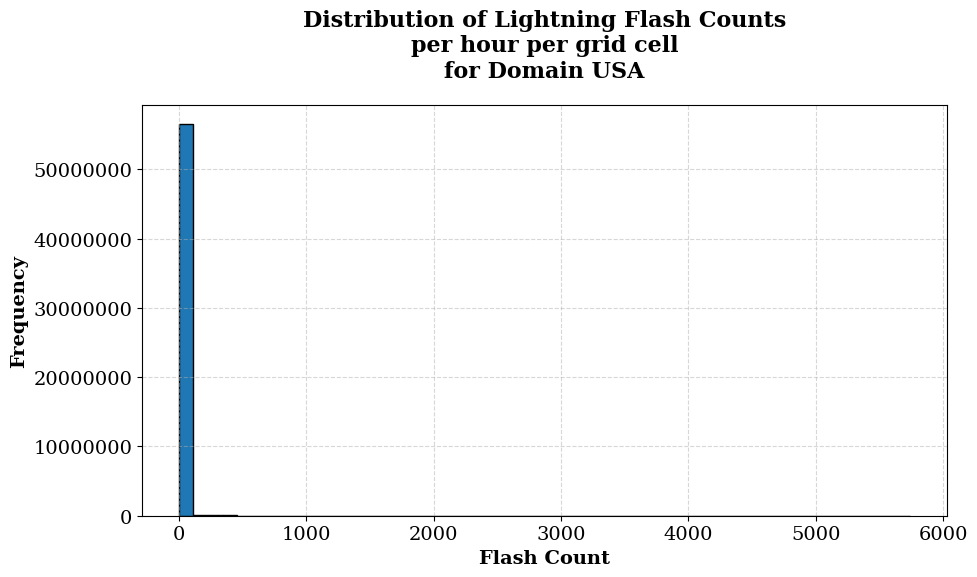

In [31]:
from matplotlib.ticker import ScalarFormatter


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # professional, Times-like
    "font.size": 14
})


plt.figure(figsize=(10,6))

# Plot histogram
plt.hist(flash_values, bins=50, range=(0, flash_values.max()), 
         edgecolor='black', color="#1f77b4")  # nicer color

# Force y-axis to show full numbers, not scientific notation
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.gca().ticklabel_format(axis='y', style='plain')

# Labels and title with professional font and bold
plt.xlabel("Flash Count", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of Lightning Flash Counts\nper hour per grid cell\nfor Domain USA", fontsize=16, fontweight='bold', pad=20)

# Add light grid
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()



In [31]:
# #By using the isel() we will be able to filter the data according to the valid flash stamps
# flash_event_cape_amazon = cape_data_amazon.sel(Datetime=valid_time_indices_amazon)  # Replace 'Datetime' with the correct coordinate name if necessary
# flash_event_cnvpre_amazon = convpre_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_massflux_amazon = massflux_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_cloudfrac_amazon = cloudfrac_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_iwc440_amazon = iwc440_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_cldht_amazon = cldht_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_tlapse_amazon = tlapse_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_mseratio_amazon = mseratio_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_crh_amazon = crh_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_MaxFrac_amazon = MaxFrac_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_pretot_amazon = pretot_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_iceflux_amazon = iceflux_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flash_event_LCL_amazon = LCL_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_LWI_amazon = LWI_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_lopez_amazon = lopez_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_BC_amazon = BC_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_BR_amazon = BR_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_PMCoarse_amazon = pmcoarse_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_PMCfine_amazon = pmfine_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_Seasalt_amazon = Seasalt_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_Dust_amazon = Dust_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_Nitrate_amazon = Nitrate_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_Sulfate_amazon = Sulfate_data_amazon.sel(Datetime=valid_time_indices_amazon)
# flashevent_OC_amazon = OC_data_amazon.sel(Datetime=valid_time_indices_amazon)

In [32]:
# flashevent_flash_amazon = flash_data_amazon.sel(Datetime=valid_time_indices_amazon)

In [33]:
# flash_values = flashevent_flash_amazon["flashes"].values.flatten()

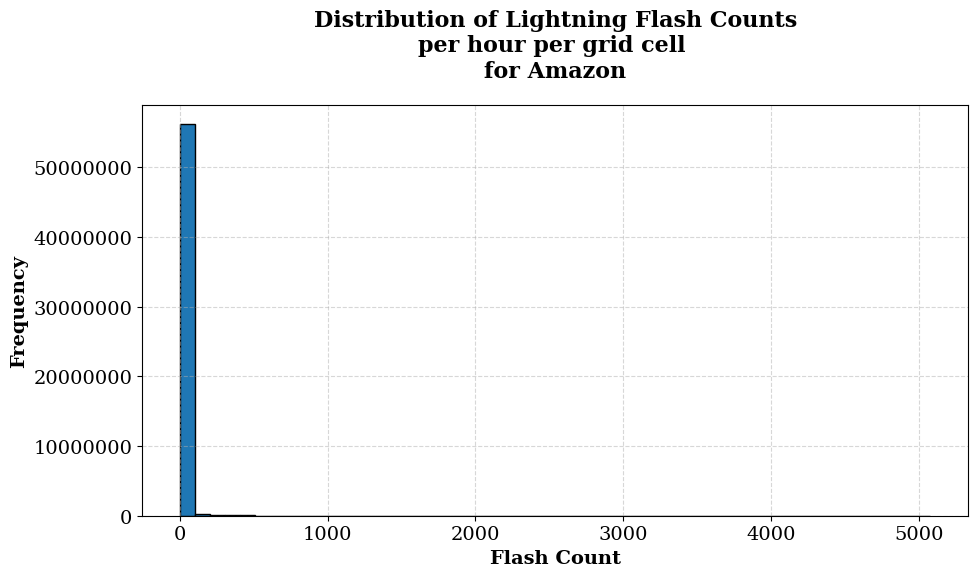

In [35]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # professional, Times-like
    "font.size": 14
})


plt.figure(figsize=(10,6))

# Plot histogram
plt.hist(flash_values, bins=50, range=(0, flash_values.max()), 
         edgecolor='black', color="#1f77b4")  # nicer color

# Force y-axis to show full numbers, not scientific notation
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.gca().ticklabel_format(axis='y', style='plain')

# Labels and title with professional font and bold
plt.xlabel("Flash Count", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of Lightning Flash Counts\nper hour per grid cell \nfor Amazon", fontsize=16, fontweight='bold', pad=20)

# Add light grid
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()



Okay, now I have my samples that have at least one flash event on the 64x64 grid. The task now is to get the samples where the flash event lines up with a nonzero value for convective precipitation. This ensures at least one grid cell has a non zero cnv. precip value and flash value at the same location. 

In [25]:
# Step 1: Create boolean masks
convpre_nonzero = flash_event_cnvpre['precon'] > 1e-10  # Mask for nonzero convective precip
flash_nonzero = valid_samples['flashes'] > 0  # Mask for nonzero flashes
# Step 2: Find overlapping points
overlapping_mask = convpre_nonzero & flash_nonzero

# Step 3: Reduce along lat/lon dimensions to find valid samples
valid_samples_mask = overlapping_mask.any(dim=['Latitudes', 'Longitudes'])

# Step 4: Compute the mask (resolve Dask array issue)
valid_samples_mask = valid_samples_mask.compute()

# Step 5: Extract valid timestamps using the computed mask
valid_timestamps = valid_samples['Datetime'].where(valid_samples_mask, drop=True).values

In [26]:
print(len(valid_timestamps))

3800


In [27]:
# # Step 1: Create boolean masks
# convpre_nonzero_ama = flash_event_cnvpre_amazon['precon'] > 1e-10  # Mask for nonzero convective precip
# flash_nonzero_ama = valid_samples_amazon['flashes'] > 0  # Mask for nonzero flashes
# # Step 2: Find overlapping points
# overlapping_mask_ama = convpre_nonzero_ama & flash_nonzero_ama

# # Step 3: Reduce along lat/lon dimensions to find valid samples
# valid_samples_mask_ama = overlapping_mask_ama.any(dim=['Latitudes', 'Longitudes'])

# # Step 4: Compute the mask (resolve Dask array issue)
# valid_samples_mask_ama = valid_samples_mask_ama.compute()

# # Step 5: Extract valid timestamps using the computed mask
# valid_timestamps_amazon = valid_samples_amazon['Datetime'].where(valid_samples_mask_ama, drop=True).values

In [28]:
convpre_grid = flash_event_cnvpre.sel(Datetime=valid_timestamps)['precon']
massflux_grid = flashevent_massflux.sel(Datetime=valid_timestamps)['cnv_mfc_440']
cloudfrac_grid = flashevent_cloudfrac.sel(Datetime=valid_timestamps)['cldfrac_conv_440']
flash_grid = valid_samples.sel(Datetime=valid_timestamps)['flashes']
cape_grid = flash_event_cape.sel(Datetime=valid_timestamps)['cape']
iwc440_grid = flashevent_iwc440.sel(Datetime=valid_timestamps)['iwc_440']
cldht_grid = flash_event_cldht.sel(Datetime=valid_timestamps)['z_cldht']
tlapse_grid = flash_event_tlapse.sel(Datetime=valid_timestamps)['t_lapserate']
mseratio_grid = flash_event_mseratio.sel(Datetime=valid_timestamps)['mse_ratio']
crh_grid = flash_event_crh.sel(Datetime=valid_timestamps)['crh']
MaxFrac_grid = flash_event_MaxFrac.sel(Datetime=valid_timestamps)['clcn_colmax']
pretot_grid = flash_event_pretot.sel(Datetime=valid_timestamps)['pretot']
iceflux_grid = flash_event_iceflux.sel(Datetime=valid_timestamps)['pfi_cn_colmax']
LCL_grid = flash_event_LCL.sel(Datetime=valid_timestamps)['lcl_moist']
LWI_grid = flashevent_LandOcean.sel(Datetime=valid_timestamps)['lwi']
MTG_grid = flashevent_flash_MTG.sel(Datetime=valid_timestamps)['flashes']
Lopez_grid = flashevent_lopez.sel(Datetime=valid_timestamps)['lfr']
# PMCoarse_grid = flashevent_PMCoarse.sel(Datetime=valid_timestamps)['pm_coarse']
# PMFine_grid = flashevent_PMCfine.sel(Datetime=valid_timestamps)['pm_fine']
# BC_grid = flashevent_BC.sel(Datetime=valid_timestamps)['tau_bc_ext']
# BR_grid = flashevent_BR.sel(Datetime=valid_timestamps)['tau_br_ext']
# OC_grid = flashevent_OC.sel(Datetime=valid_timestamps)['tau_oc_ext']
# Dust_grid = flashevent_Dust.sel(Datetime=valid_timestamps)['tau_du_ext']
# SS_grid = flashevent_Seasalt.sel(Datetime=valid_timestamps)['tau_ss_ext']
# Sulfate_grid = flashevent_Sulfate.sel(Datetime=valid_timestamps)['tau_su_ext']
# Nitrate_grid = flashevent_Nitrate.sel(Datetime=valid_timestamps)['tau_ni_ext']

In [37]:
# #For the Amazon Data
# convpre_grid_amazon = flash_event_cnvpre_amazon.sel(Datetime=valid_timestamps_amazon)['precon']
# massflux_grid_amazon = flashevent_massflux_amazon.sel(Datetime=valid_timestamps_amazon)['cnv_mfc_440']
# cloudfrac_grid_amazon = flashevent_cloudfrac_amazon.sel(Datetime=valid_timestamps_amazon)['cldfrac_conv_440']
# flash_grid_amazon = valid_samples_amazon.sel(Datetime=valid_timestamps_amazon)['flashes']
# cape_grid_amazon = flash_event_cape_amazon.sel(Datetime=valid_timestamps_amazon)['cape']
# iwc440_grid_amazon = flashevent_iwc440_amazon.sel(Datetime=valid_timestamps_amazon)['iwc_440']
# cldht_grid_amazon = flash_event_cldht_amazon.sel(Datetime=valid_timestamps_amazon)['z_cldht']
# tlapse_grid_amazon = flash_event_tlapse_amazon.sel(Datetime=valid_timestamps_amazon)['t_lapserate']
# mseratio_grid_amazon = flash_event_mseratio_amazon.sel(Datetime=valid_timestamps_amazon)['mse_ratio']
# crh_grid_amazon = flash_event_crh_amazon.sel(Datetime=valid_timestamps_amazon)['crh']
# MaxFrac_grid_amazon = flash_event_MaxFrac_amazon.sel(Datetime=valid_timestamps_amazon)['clcn_colmax']
# pretot_grid_amazon= flash_event_pretot_amazon.sel(Datetime=valid_timestamps_amazon)['pretot']
# iceflux_grid_amazon = flash_event_iceflux_amazon.sel(Datetime=valid_timestamps_amazon)['pfi_cn_colmax']
# LCL_grid_amazon = flash_event_LCL_amazon.sel(Datetime=valid_timestamps_amazon)['lcl_moist']
# LWI_grid_amazon = flashevent_LWI_amazon.sel(Datetime=valid_timestamps_amazon)['lwi']
# Lopez_grid_amazon = flashevent_lopez_amazon.sel(Datetime=valid_timestamps_amazon)['lfr']
# PMCoarse_grid_amazon = flashevent_PMCoarse_amazon.sel(Datetime=valid_timestamps_amazon)['pm_coarse']
# PMFine_grid_amazon = flashevent_PMCfine_amazon.sel(Datetime=valid_timestamps_amazon)['pm_fine']
# BC_grid_amazon = flashevent_BC_amazon.sel(Datetime=valid_timestamps_amazon)['tau_bc_ext']
# BR_grid_amazon = flashevent_BR_amazon.sel(Datetime=valid_timestamps_amazon)['tau_br_ext']
# OC_grid_amazon = flashevent_OC_amazon.sel(Datetime=valid_timestamps_amazon)['tau_oc_ext']
# Dust_grid_amazon = flashevent_Dust_amazon.sel(Datetime=valid_timestamps_amazon)['tau_du_ext']
# SS_grid_amazon = flashevent_Seasalt_amazon.sel(Datetime=valid_timestamps_amazon)['tau_ss_ext']
# Sulfate_grid_amazon = flashevent_Sulfate_amazon.sel(Datetime=valid_timestamps_amazon)['tau_su_ext']
# Nitrate_grid_amazon = flashevent_Nitrate_amazon.sel(Datetime=valid_timestamps_amazon)['tau_ni_ext']

Previously, we wanted to cross check the CAPE NaN values with Convective Precipitation to see if it was a valid assumption to turn the NaN value to zero for CAPE. 
Now, we want to just turn all NaN values of CAPE into zero without the use of cross checking other variables...

In [29]:
#Replace all Nan values in CAPE with Zero. No constraints. 
cape_grid = cape_grid.where(~np.isnan(cape_grid), 0)
#cape_grid_amazon = cape_grid_amazon.where(~np.isnan(cape_grid_amazon), 0)

In [30]:
#Replace all Nan values in Cloudheight with Zero. No constraints. 
cldht_grid = cldht_grid.where(~np.isnan(cldht_grid), 0)
#cldht_grid_amazon = cldht_grid_amazon.where(~np.isnan(cldht_grid_amazon), 0)

In [31]:
# Step 1: Check for NaN values in the CAPE dataset
nan_mask = cape_grid.isnull()
# Step 2: Check for samples that have no NaN values across each 32x32 grid
samples_with_no_nan = ~nan_mask.any(dim=('Latitudes', 'Longitudes'))
# Compute the mask explicitly to avoid Dask-related issues
samples_with_no_nan = samples_with_no_nan.compute()

In [41]:
# # Step 1: Check for NaN values in the CAPE dataset
# nan_mask_ama = cape_grid_amazon.isnull()
# # Step 2: Check for samples that have no NaN values across each 32x32 grid
# samples_with_no_nan_ama = ~nan_mask_ama.any(dim=('Latitudes', 'Longitudes'))
# # Compute the mask explicitly to avoid Dask-related issues
# samples_with_no_nan_ama = samples_with_no_nan_ama.compute()

In [32]:
# Step 3: Apply the mask to the CAPE dataset to select the samples with no NaN values
cape_no_nan = cape_grid.where(samples_with_no_nan, drop=True)
convpre_no_nan = convpre_grid.where(samples_with_no_nan, drop=True)
massflux_no_nan = massflux_grid.where(samples_with_no_nan, drop=True)
cloudfrac_no_nan = cloudfrac_grid.where(samples_with_no_nan, drop=True)
iwc440_no_nan = iwc440_grid.where(samples_with_no_nan, drop=True)
cldht_no_nan = cldht_grid.where(samples_with_no_nan, drop=True)
tlapse_no_nan = tlapse_grid.where(samples_with_no_nan, drop=True)
mseratio_no_nan = mseratio_grid.where(samples_with_no_nan, drop=True)
crh_no_nan = crh_grid.where(samples_with_no_nan, drop=True)
MaxFrac_no_nan = MaxFrac_grid.where(samples_with_no_nan, drop=True)
totPrecip_no_nan = pretot_grid.where(samples_with_no_nan, drop=True)
iceflux_no_nan = iceflux_grid.where(samples_with_no_nan, drop=True)
LCL_no_nan = LCL_grid.where(samples_with_no_nan, drop=True)
flash_no_non = flash_grid.where(samples_with_no_nan, drop=True)
LWI_no_nan = LWI_grid.where(samples_with_no_nan, drop=True)
MTG_no_nan = MTG_grid.where(samples_with_no_nan, drop=True)
Lopez_no_nan = Lopez_grid.where(samples_with_no_nan, drop=True)
# PMcoarse_no_nan = PMCoarse_grid.where(samples_with_no_nan, drop=True)
# PMfine_no_nan = PMFine_grid.where(samples_with_no_nan, drop=True)
# OC_no_nan = OC_grid.where(samples_with_no_nan, drop=True)
# BC_no_nan = BC_grid.where(samples_with_no_nan, drop=True)
# BR_no_nan = BR_grid.where(samples_with_no_nan, drop=True)
# Dust_no_nan = Dust_grid.where(samples_with_no_nan, drop=True)
# SS_no_nan = SS_grid.where(samples_with_no_nan, drop=True)
# SU_no_nan = Sulfate_grid.where(samples_with_no_nan, drop=True)
# Nitrate_no_nan = Nitrate_grid.where(samples_with_no_nan, drop=True)
#THE LWI variable is not to be scaled. Save as is right now. 

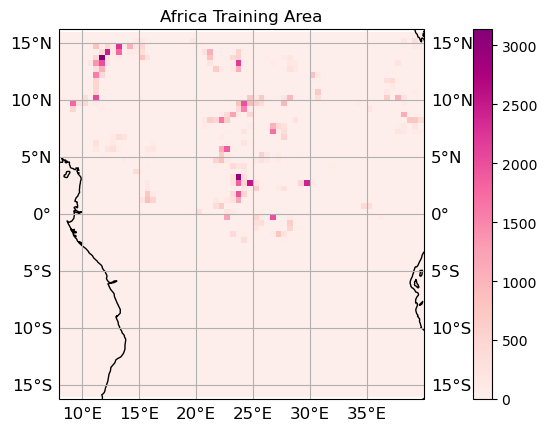

In [67]:
#Shows the training area for the USA
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Shows the training area for New Domain
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
#This is for the US
def truncate_colormap(cmap, minval=0.05, maxval=0.85, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Create lighter version of RdPu
light_rdpu = truncate_colormap(plt.get_cmap('RdPu'), 0.05, 0.85)

# Select the specific time slice
lwi_slice = MTG_no_nan.isel(Datetime=1)

# Create a plot with Cartopy
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data with the new lightened colormap
plot = lwi_slice.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap=light_rdpu, add_colorbar=False
)

# Add and label the colorbar
cbar = plt.colorbar(plot, ax=ax, orientation='vertical', pad=0.1, fraction=0.046)
#cbar.set_label("Land (1) Ocean (0)")

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES, linestyle=':')

# Add styled gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.color = 'grey'
gl.linewidth = 1
gl.xlabel_style = {'fontsize': 12}
gl.ylabel_style = {'fontsize': 12}


# Set extent and title
ax.set_extent([8, 40, -16, 16])
ax.set_title('Africa Training Area', fontsize = 12)

plt.show()

In [33]:
#Conversion 
#This is for the conversion of the Lopez data to flashes/hour: 
# Extract 1-D lat/lon
lats = Lopez_no_nan.Latitudes.values   # shape (64,)
lons = Lopez_no_nan.Longitudes.values  # shape (64,)

# Convert degrees → radians
lat_rad = np.deg2rad(lats)
lon_rad = np.deg2rad(lons)

# Earth radius (km)
R = 6371.0

# Because resolution is 0.5°, each cell spans ±0.25° from center
lat_edges_lower = np.deg2rad(lats - 0.25)
lat_edges_upper = np.deg2rad(lats + 0.25)

# Δ(sin(lat)) for each latitude row (64 values)
d_sin_lat = np.sin(lat_edges_upper) - np.sin(lat_edges_lower)

# Longitude spacing (constant for all columns)
dlon = np.deg2rad(0.5)   # radians

# Area formula for each latitude band:
# area(lat, lon) = R^2 * dlon * Δ(sin(lat))
area_1d = (R**2) * dlon * d_sin_lat    # shape (64,)

# Expand to 2-D: (Latitudes, Longitudes)
area_2d = np.outer(area_1d, np.ones_like(lons))

# Wrap as DataArray for broadcasting
area_da_africa = xr.DataArray(
    area_2d,
    coords={"Latitudes": lats, "Longitudes": lons},
    dims=("Latitudes", "Longitudes"),
    name="cell_area_km2"
)

In [34]:
# Multiply by grid-cell area and by seconds per hour
lfr_flashes_hour = (Lopez_no_nan * area_da_africa) * 3600

# Rename for clarity
lfr_flashes_hour_africa = lfr_flashes_hour.rename("Lopez_flashes")

In [35]:
lfr_flashes_hour_africa

<xarray.DataArray 'Lopez_flashes' (Latitudes: 50, Longitudes: 50, Datetime: 3800)>
dask.array<mul, shape=(50, 50, 3800), dtype=float32, chunksize=(50, 50, 740), chunktype=numpy.ndarray>
Coordinates:
  * Longitudes  (Longitudes) float32 -14.75 -14.25 -13.75 ... 8.75 9.25 9.75
  * Latitudes   (Latitudes) float32 5.25 5.75 6.25 6.75 ... 28.75 29.25 29.75
  * Datetime    (Datetime) datetime64[ns] 2024-07-04T14:00:00 ... 2024-12-31T...

In [108]:
#For the Histogram
# Extract the data as a flattened 1D NumPy array
# flat_cape = cape_no_nan.values.flatten()
# flat_convpre = convpre_no_nan.values.flatten()
# flat_massflux = massflux_no_nan.values.flatten()
# flat_cloudfrac = cloudfrac_no_nan.values.flatten()
# flat_iwc440 = iwc440_no_nan.values.flatten()
# flat_cloudheight = cldht_no_nan.values.flatten()
#flat_tlapse = tlapse_no_nan.values.flatten()
#flat_mse = mseratio_no_nan.values.flatten()
#flat_crh = crh_no_nan.values.flatten()
#flat_maxfrac = MaxFrac_no_nan.values.flatten()
#flat_totprecip = totPrecip_no_nan.values.flatten()
#flat_iceflux = iceflux_no_nan.values.flatten()
#flat_lcl = LCL_no_nan.values.flatten()
flat_lopez = Lopez_no_nan.values.flatten()

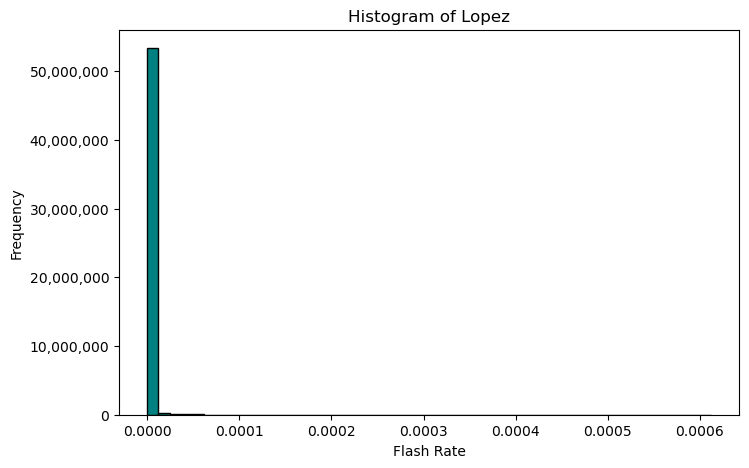

In [109]:
#This is a histogram of the Flash data. With no normalization technique. 
import matplotlib.ticker as ticker
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(flat_lopez, bins=50, color='teal', edgecolor='black')
plt.title('Histogram of Lopez')
plt.xlabel('Flash Rate')
plt.ylabel('Frequency')
#plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [55]:
#cape_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/cape_usa_new.nc')
#convpre_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/convpre_usa_new.nc')
#massflux_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/massflux_usa_new.nc')
#cloudfrac_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/cloudfrac_usa_new.nc')
#iwc440_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/iwc440_usa_new.nc')
#cldht_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/cldht_usa_new.nc')
#tlapse_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/tlapse_usa_new.nc')
#crh_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/crh_usa_new.nc')
#mseratio_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/mseratio_usa_new.nc')
#MaxFrac_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/maxfrac_usa_new.nc')
#totPrecip_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/totprecip_usa_new.nc')
#iceflux_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/iceflux_usa_new.nc')
#LCL_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/LCL_usa_new.nc')

In [36]:
cape_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/cape_smallafrica.nc')
convpre_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/convpre_smallafrica.nc')
massflux_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/massflux_smallafrica.nc')
cloudfrac_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/cloudfrac_smallafrica.nc')
iwc440_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/iwc440_smallafrica.nc')
cldht_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/cldht_smallafrica.nc')
tlapse_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/tlapse_smallafrica.nc')
crh_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/crh_smallafrica.nc')
mseratio_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/mseratio_smallafrica.nc')
MaxFrac_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/maxfrac_smallafrica.nc')
totPrecip_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/totprecip_smallafrica.nc')
iceflux_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/iceflux_smallafrica.nc')
LCL_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/LCL_smallafrica.nc')

In [37]:
LWI_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/LWI_smallafrica.nc')

In [38]:
#MTG Data
MTG_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/MTG_smallafrica.nc')

In [79]:
LWI_no_nan

<xarray.DataArray 'lwi' (Latitudes: 64, Longitudes: 64, Datetime: 13209)>
dask.array<where, shape=(64, 64, 13209), dtype=float32, chunksize=(64, 64, 744), chunktype=numpy.ndarray>
Coordinates:
  * Longitudes  (Longitudes) float32 -129.8 -129.2 -128.8 ... -98.75 -98.25
  * Latitudes   (Latitudes) float32 -11.75 -11.25 -10.75 ... 18.75 19.25 19.75
  * Datetime    (Datetime) datetime64[ns] 2023-06-01T01:00:00 ... 2025-01-01
Attributes:
    long_name:      lwi
    units:          1
    var_desc:       land(1)_water(0)_ice(2)_flag
    missing_value:  nan

In [39]:
#LWI variable 
#LWI_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/pacific/LWI_pacific.nc')
#Lopez Flashes
lfr_flashes_hour_africa.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/Africa/Lopez_smallafrica.nc')

In [111]:
# #Aerosol Data to Netcdf. 
# PMcoarse_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/PMcoarse_usa_new.nc')
# PMfine_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/PMfine_usa_new.nc')
# BC_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/BC_usa_new.nc')
# BR_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/BR_usa_new.nc')
# OC_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/OC_usa_new.nc')
# Dust_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/Dust_usa_new.nc')
# SS_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/SS_usa_new.nc')
# SU_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/SU_usa_new.nc')
# Nitrate_no_nan.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/usa/Nitrate_usa_new.nc')

In [43]:
# cape_amazon = cape_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# convpre_amazon = convpre_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# massflux__amazon = massflux_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# cloudfrac_amazon = cloudfrac_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# iwc440_amazon = iwc440_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# cldht_amazon = cldht_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# tlapse_amazon = tlapse_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# mseratio_amazon = mseratio_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# crh_amazon = crh_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# MaxFrac_amazon = MaxFrac_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# totPrecip_amazon = pretot_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# iceflux_amazon = iceflux_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# LCL_amazon = LCL_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# flash_amazon = flash_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# LWI_amazon = LWI_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# Lopez_amazon = Lopez_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# PMcoarse_amazon = PMCoarse_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# PMfine_amazon = PMFine_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# OC_amazon = OC_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# BC_amazon = BC_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# BR_amazon = BR_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# Dust_amazon = Dust_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# SS_amazon = SS_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# SU_amazon = Sulfate_grid_amazon.where(samples_with_no_nan_ama, drop=True)
# Nitrate_amazon = Nitrate_grid_amazon.where(samples_with_no_nan_ama, drop=True)

In [113]:
#Amazon Conversion 
#This is for the conversion of the Lopez data to flashes/hour: 
# Extract 1-D lat/lon
lats = Lopez_amazon.Latitudes.values   # shape (64,)
lons = Lopez_amazon.Longitudes.values  # shape (64,)

# Convert degrees → radians
lat_rad = np.deg2rad(lats)
lon_rad = np.deg2rad(lons)

# Earth radius (km)
R = 6371.0

# Because resolution is 0.5°, each cell spans ±0.25° from center
lat_edges_lower = np.deg2rad(lats - 0.25)
lat_edges_upper = np.deg2rad(lats + 0.25)

# Δ(sin(lat)) for each latitude row (64 values)
d_sin_lat = np.sin(lat_edges_upper) - np.sin(lat_edges_lower)

# Longitude spacing (constant for all columns)
dlon = np.deg2rad(0.5)   # radians

# Area formula for each latitude band:
# area(lat, lon) = R^2 * dlon * Δ(sin(lat))
area_1d = (R**2) * dlon * d_sin_lat    # shape (64,)

# Expand to 2-D: (Latitudes, Longitudes)
area_2d = np.outer(area_1d, np.ones_like(lons))

# Wrap as DataArray for broadcasting
area_da_amazon = xr.DataArray(
    area_2d,
    coords={"Latitudes": lats, "Longitudes": lons},
    dims=("Latitudes", "Longitudes"),
    name="cell_area_km2"
)

In [114]:
# Multiply by grid-cell area and by seconds per hour
lfr_flashes_hour_ama = (Lopez_amazon * area_da_amazon) * 3600

# Rename for clarity
lfr_flashes_hour_ama = lfr_flashes_hour_ama.rename("Lopez_flashes_usa")


In [71]:
#cape_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/cape_amazon_new.nc')
#convpre_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/convpre_amazon_new.nc')
#massflux__amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/massflux_amazon_new.nc')
#cloudfrac_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/cloudfrac_amazon_new.nc')
#iwc440_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/iwc440_amazon_new.nc')
#cldht_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/cldht_amazon_new.nc')
#tlapse_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/tlapse_amazon_new.nc')
#crh_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/crh_amazon_new.nc')
#mseratio_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/mseratio_amazon_new.nc')
#MaxFrac_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/maxfrac_amazon_new.nc')
#totPrecip_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/totprecip_amazon_new.nc')
#iceflux_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/iceflux_amazon_new.nc')
#LCL_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/LCL_amazon_new.nc')

In [47]:
#LWI variable Amazon
#LWI_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/LWI_usa_new.nc')
#Lopez variable Amazon
#lfr_flashes_hour_ama.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_variables/amazon/lopez_amazon.nc')

Length of flash data is how many individual grid cells I have in the entire dataset:  1


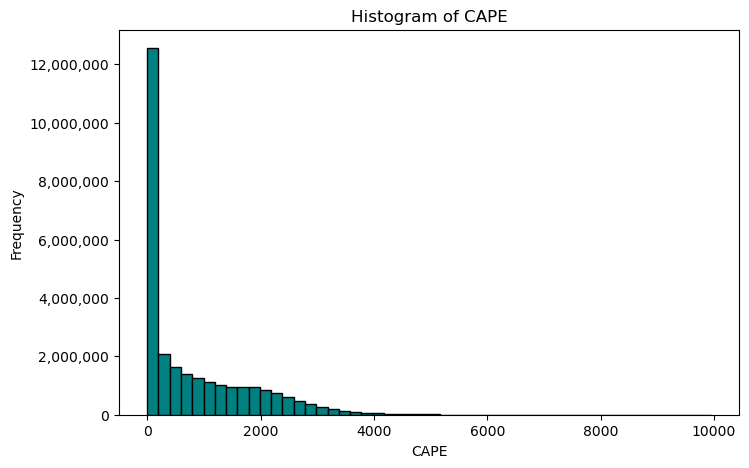

In [55]:
#This is a histogram of the Flash data. With no normalization technique. 
import matplotlib.ticker as ticker
# Extract the data as a flattened 1D NumPy array
data = cape_data['cape'].values.flatten()
print("Length of flash data is how many individual grid cells I have in the entire dataset: ", len(flash_data))
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(data, bins=50, color='teal', edgecolor='black')
plt.title('Histogram of CAPE')
plt.xlabel('CAPE')
plt.ylabel('Frequency')
# Force full numbers instead of scientific notation
#plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

Okay these should all be saved out. They are pre-processed, but have not been Zscored. That will come in the
NN code. 

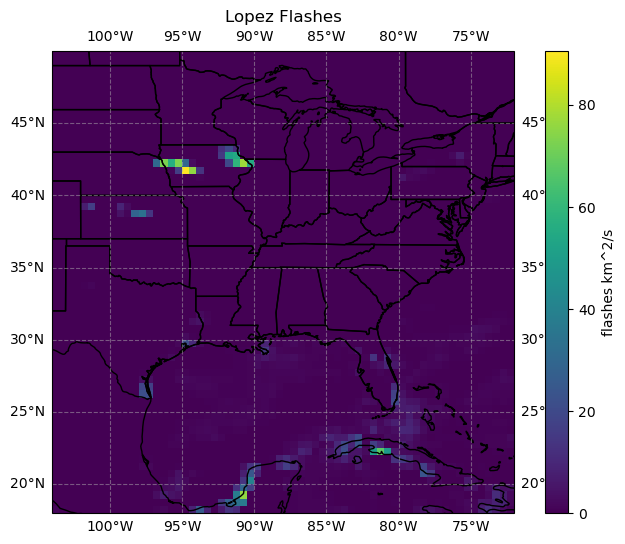

In [50]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select one sample (e.g., the first datetime index)
sample_index = 1000  # Change this to select another time
sample = lfr_flashes_hour.isel(Datetime=sample_index)

# Get lat and lon coordinates
lats = sample["Latitudes"]
lons = sample["Longitudes"]

# Create figure with projection
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot CAPE data
pcm = ax.pcolormesh(lons, lats, sample, cmap="viridis", shading="auto")

# Add state boundaries
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1)
# Add country borders (for Mexico & U.S.)
#ax.add_feature(cfeature.BORDERS, edgecolor="red", linewidth=1.5)  # Red for clarity
# Add coastlines for reference
ax.coastlines()

# Add gridlines
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", label = 'flashes km^2/s')

# Set title
ax.set_title(f"Lopez Flashes")

plt.show()


In [40]:
#USA flash labels 
labels_dataset = xr.Dataset({
    "flashes": flash_no_non, 
})

In [45]:
#Amazon Flash labels
labels_dataset_amazon = xr.Dataset({
    "flashes": flash_amazon, 
})

In [41]:
flashes = labels_dataset['flashes']
#flashes_amazon = labels_dataset_amazon['flashes']

In [42]:
# per-timestep totals (optional, if you want them too)
total_before = flashes.sum(dim=("Latitudes", "Longitudes"))

# grand total (all grid cells, all timesteps)
grand_total = float((flashes.values.sum()))

print("Grand total flashes:", grand_total)


Grand total flashes: 53606504.0


Length of flash data is how many individual grid cells I have in the entire dataset:  42029056


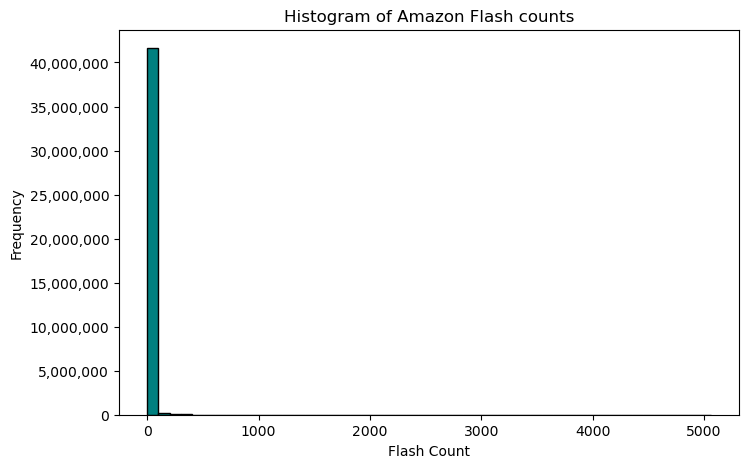

In [83]:
#This is a histogram of the Flash data. With no normalization technique. 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Extract the data as a flattened 1D NumPy array
flash_data = flashes_amazon.values.flatten()
print("Length of flash data is how many individual grid cells I have in the entire dataset: ", len(flash_data))
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(flash_data, bins=50, color='teal', edgecolor='black')
plt.title('Histogram of Amazon Flash counts')
plt.xlabel('Flash Count')
plt.ylabel('Frequency')
# Force full numbers instead of scientific notation
#plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


Now it is time to log transform. I can do this using x+epsilon or x+1. I will need to decide which is better. 
I can do both. 

In [42]:
#Transform the US flash data.
flashes_log_usa = xr.DataArray(
    np.log10(flashes + 1),   # elementwise log10
    dims=flashes.dims,
    coords=flashes.coords,
    name="flashes_log"
)


In [43]:
labels_dataset

<xarray.Dataset>
Dimensions:     (Longitudes: 64, Latitudes: 64, Datetime: 13209)
Coordinates:
  * Longitudes  (Longitudes) float32 -129.8 -129.2 -128.8 ... -98.75 -98.25
  * Latitudes   (Latitudes) float32 -11.75 -11.25 -10.75 ... 18.75 19.25 19.75
  * Datetime    (Datetime) datetime64[ns] 2023-06-01T01:00:00 ... 2025-01-01
Data variables:
    flashes     (Latitudes, Longitudes, Datetime) float32 dask.array<chunksize=(64, 64, 718), meta=np.ndarray>

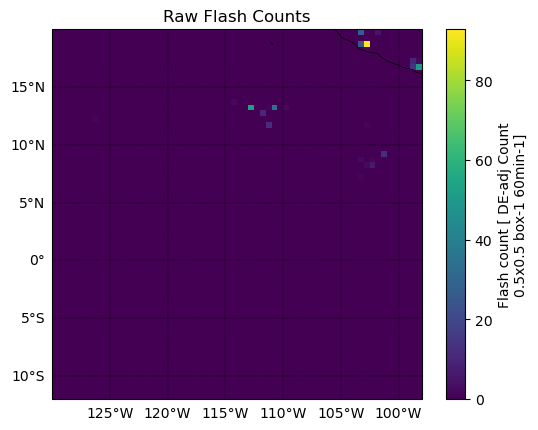

In [46]:
# Create a plot with a PlateCarree projection (common for Lat/Lon data)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

# Plot your data (xarray automatically detects lat/lon)
labels_dataset['flashes'].isel(Datetime=500).plot(ax=ax, transform=ccrs.PlateCarree(),cmap='viridis')
# Add fast-loading features
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)               # State/province lines

# ✅ Add gridlines and lat/lon labels
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='black', linestyle = '--')
gl.top_labels = False    # Hide top x-axis labels
gl.right_labels = False  # Hide right y-axis labels
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax.set_xlabel("Longitude")
plt.title("Raw Flash Counts")
#plt.imshow(flashes_log_usa, vmin=0)  # force minimum color at 0
plt.show()

plot some time steps of the logged flashes. See what it looks like on the grid space.
plot some of the unlogged and some of the logged samples for the same datetime. 

In [43]:
# flashes_log_da is your log10-transformed DataArray
flashes_unlog_da = xr.DataArray(
    10**flashes_log_usa - 1,  # inverse transform
    dims=flashes_log_usa.dims,
    coords=flashes_log_usa.coords,
    name="flashes_unlog"
)
#This is to make sure I can get back to the original values. 

In [44]:
# grand total (all grid cells, all timesteps)
grand_total_undone = float((flashes_unlog_da.values.sum()))

print("Grand total flashes:", grand_total_undone)

Grand total flashes: 23146548.0


In [46]:
#Raw data (grand_total) - data that has been logged and unlogged. 
diff = grand_total - grand_total_undone
print(diff)

0.0


In [47]:
# check the max absolute per-element difference
max_diff = float(np.abs(flashes.values - flashes_unlog_da.values).max())
print("Max absolute difference per cell:", max_diff)


Max absolute difference per cell: 0.0009765625


In [50]:
#Transform the Amazon flash data.
flashes_log_amazon = xr.DataArray(
    np.log10(flashes_amazon + 1),   # elementwise log10
    dims=flashes_amazon.dims,
    coords=flashes_amazon.coords,
    name="flashes_log"
)

Length of flash data is how many individual grid cells I have in the entire dataset:  42029056


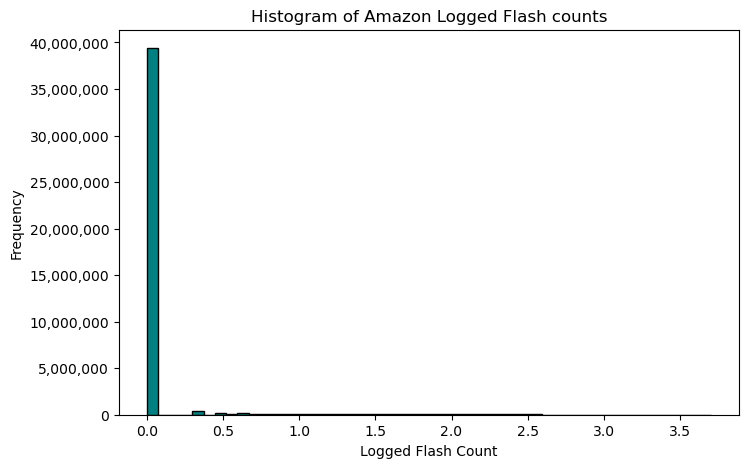

In [108]:
#Histogram of the logged flashes. 
# Extract the data as a flattened 1D NumPy array
flash_data = flashes_log_amazon.values.flatten()
print("Length of flash data is how many individual grid cells I have in the entire dataset: ", len(flash_data))
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(flash_data, bins=50, color='teal', edgecolor='black')
plt.title('Histogram of Amazon Logged Flash counts')
plt.xlabel('Logged Flash Count')
plt.ylabel('Frequency')
# Force full numbers instead of scientific notation
#plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [48]:
flashes_log_usa

<xarray.DataArray 'flashes_log' (Latitudes: 64, Longitudes: 64, Datetime: 12898)>
dask.array<log10, shape=(64, 64, 12898), dtype=float32, chunksize=(64, 64, 744), chunktype=numpy.ndarray>
Coordinates:
  * Longitudes  (Longitudes) float32 -121.8 -121.2 -120.8 ... -90.75 -90.25
  * Latitudes   (Latitudes) float32 -19.75 -19.25 -18.75 ... 10.75 11.25 11.75
  * Datetime    (Datetime) datetime64[ns] 2023-06-01T01:00:00 ... 2025-01-01

In [47]:
#Lets save the logged (x+1) flashes. 
flashes_log_usa.compute().to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_flashes/pacificflashes_new.nc')
#flashes_log_amazon.to_netcdf('/aosc/eos20/mseiler1/NN_GEOS_GLM/data/geos/variables/new_flashes/amazonflashes_new.nc')

In [117]:
#We want to do the same thing nowbut using x + epsilon instead of x + 1 
#Transform the US flash data using x + epsilon .
epsilon = 1e-6
flashes_log_usa_xE = xr.DataArray(
    np.log10(flashes + epsilon),   # elementwise log10
    dims=flashes.dims,
    coords=flashes.coords,
    name="flashes_log"
)

In [119]:
# flashes_log_da is your log10-transformed DataArray
flashes_unlog_da_XE = xr.DataArray(
    10**flashes_log_usa_xE - epsilon,  # inverse transform
    dims=flashes_log_usa_xE.dims,
    coords=flashes_log_usa_xE.coords,
    name="flashes_unlog"
)
#This is to make sure I can get back to the original values. 

In [120]:
# grand total (all grid cells, all timesteps)
grand_total_undone = float((flashes_unlog_da_XE.values.sum()))

print("Grand total flashes:", grand_total_undone)

Grand total flashes: 132643224.0


Maybe here, I should normalize the data. So that when I add it in to my NN code, it is already handled and ready to be put in the model. 